<a href="https://colab.research.google.com/github/hoonseong0/2026-BDA-repository/blob/main/%ED%83%80%EC%9D%B4%ED%83%80%EB%8B%89_%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%B6%84%EC%84%9D_%EC%B5%9C%EC%B5%9C%EC%A2%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('titanic1309.csv')

In [ ]:
# 데이터가 잘 불러와졌는지 확인하기
display(df.head(3))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [ ]:
# 나이(Age)와 요금(Fare)은 중간값으로, 탑승지(Embarked)는 가장 많은 곳으로 채웁니다.
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [ ]:
# 파생 변수 생성하기
# class: 1, 2, 3등급을 영문 이름으로 매핑
df['class'] = df['Pclass'].map({1: 'First', 2: 'Second', 3: 'Third'})

In [ ]:
# who: 16세 미만은 'child', 그 외 성별에 따라 'man' 또는 'woman'으로 구분
def get_who(row):
    if row['Age'] < 16: return 'child'
    elif row['Sex'] == 'male': return 'man'
    else: return 'woman'
df['who'] = df.apply(get_who, axis=1)

In [ ]:
# adult_male: who가 'man'인지 여부 (True/False)
df['adult_male'] = (df['who'] == 'man')

# deck: 객실 번호(Cabin)의 맨 앞 알파벳 한 글자만 추출 (없으면 NaN 유지)
df['deck'] = df['Cabin'].str[0]

# embark_town: 탑승지 알파벳을 실제 도시 이름으로 매핑
df['embark_town'] = df['Embarked'].map({'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'})

# alive: 생존 여부(0, 1)를 'no', 'yes'로 매핑
df['alive'] = df['Survived'].map({0: 'no', 1: 'yes'})

# alone: 동승한 자매/배우자(SibSp)와 부모/자식(Parch)의 합이 0이면 혼자(True)
df['alone'] = (df['SibSp'] + df['Parch']) == 0

# 전처리 후 새로 생성된 변수들 확인
display(df[['class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']].head())

,class,who,adult_male,deck,embark_town,alive,alone
0,Third,man,True,NaN,Southampton,no,False
1,First,woman,False,C,Cherbourg,yes,False
2,Third,woman,False,NaN,Southampton,yes,True
3,First,woman,False,C,Southampton,yes,False
4,Third,man,True,NaN,Southampton,no,True


In [ ]:
# 1. 탑승객 생존 여부(alive) 요약
print("📊 전체 생존/사망 인원:")
print(df['alive'].value_counts())

# 2. 남/여/아이(who) 인원 요약
print("\n📊 탑승객 유형(남/여/아이):")
print(df['who'].value_counts())

# 3. 1인 탑승(alone) 여부 요약
print("\n📊 1인 탑승 여부:")
print(df['alone'].value_counts())

📊 전체 생존/사망 인원:
alive
no     815
yes    494
Name: count, dtype: int64

📊 탑승객 유형(남/여/아이):
who
man      784
woman    410
child    115
Name: count, dtype: int64

📊 1인 탑승 여부:
alone
True     790
False    519
Name: count, dtype: int64


In [ ]:
!pip install koreanize-matplotlib
import koreanize_matplotlib
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (5, 3)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 56.8 MB/s eta 0:00:00


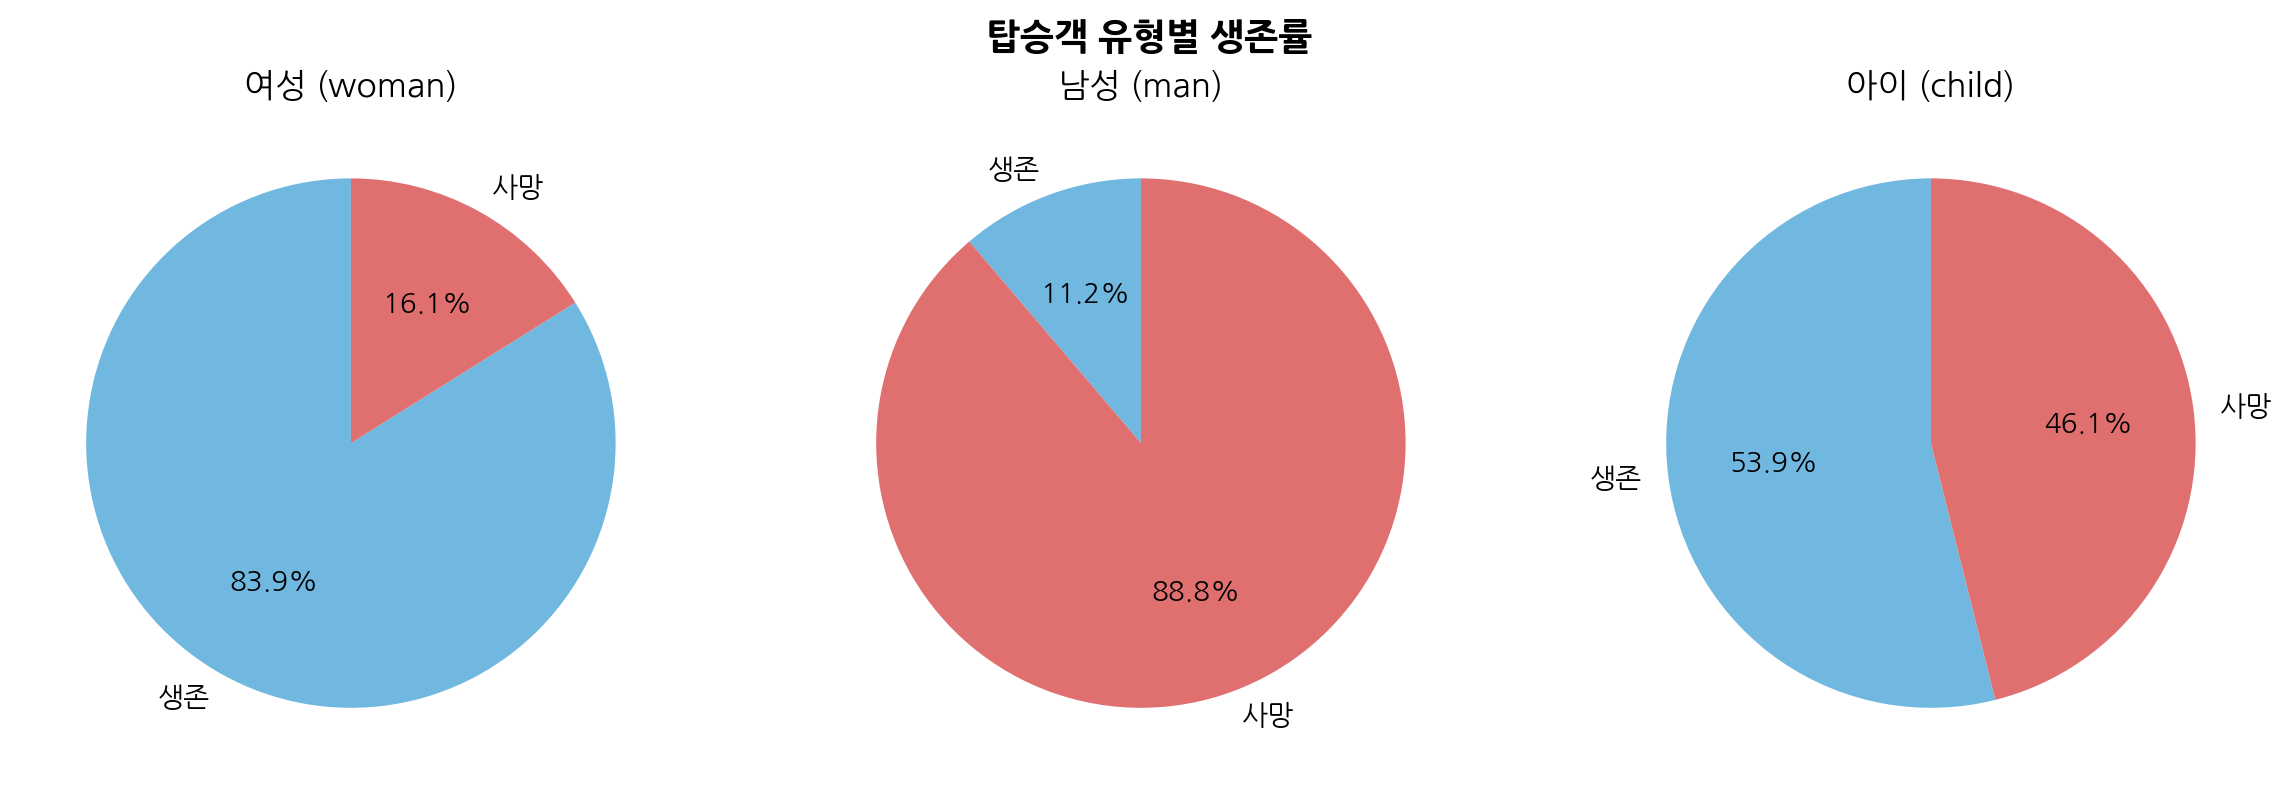

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

groups = ['woman', 'man', 'child']
titles = ['여성 (woman)', '남성 (man)', '아이 (child)']
colors = ['#70b8e0', '#e07070']

for i, (group, title) in enumerate(zip(groups, titles)):
    target = df[df['who'] == group]
    counts = target['alive'].value_counts().reindex(['yes', 'no'])

    axes[i].pie(counts,
                labels=['생존', '사망'],
                autopct='%1.1f%%',
                colors=colors,
                startangle=90)
    axes[i].set_title(title)

plt.suptitle('탑승객 유형별 생존률', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

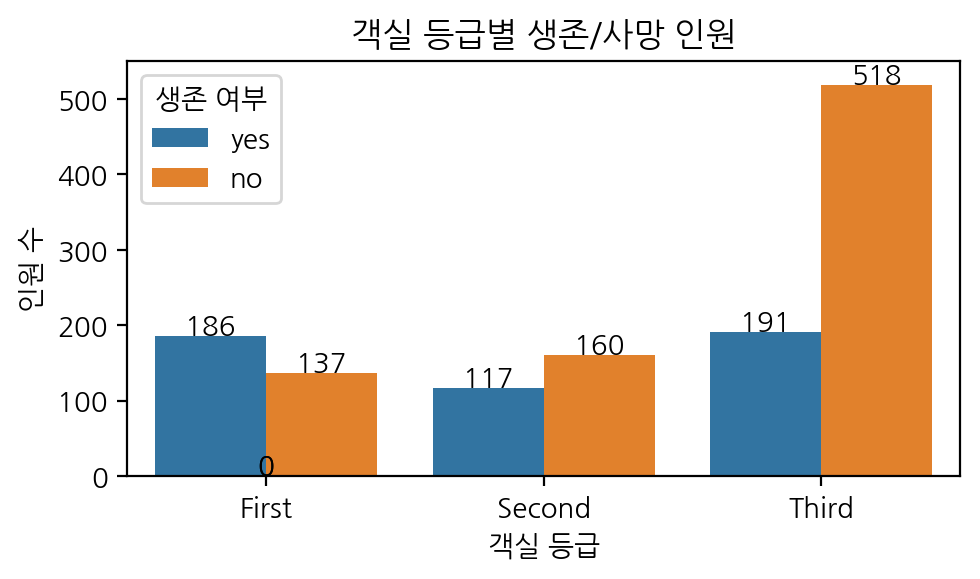

In [ ]:
# 좌석 등급이 생존에 영향을 주었는지

plt.rcParams['figure.figsize'] = (5, 3)

ax = sns.countplot(data=df, x='class', hue='alive',
                   order=['First', 'Second', 'Third'],
                   hue_order=['yes', 'no'])

for p in ax.patches:
    height = p.get_height()
    ax.text(x=(p.get_x() + p.get_width() / 2),
            y=(height + 2),
            s=int(height),
            ha='center', size=10, color='black')

ax.set_ylim(0, 550)
plt.title('객실 등급별 생존/사망 인원')
plt.xlabel('객실 등급')
plt.ylabel('인원 수')
plt.legend(title='생존 여부')
plt.tight_layout()
plt.show()

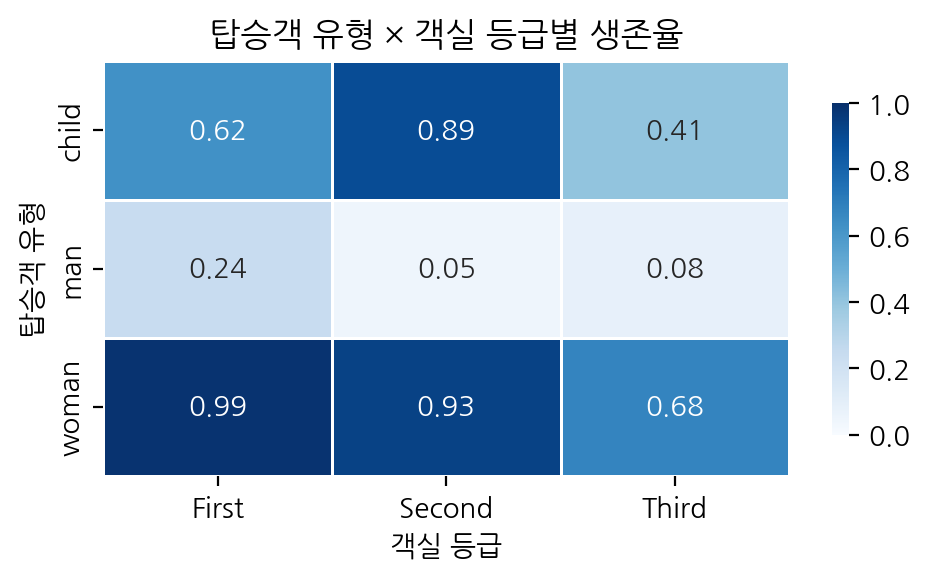

In [ ]:
# 어린아이 사망률이 높은 이유

pivot = df.pivot_table('Survived', index='who',
                       columns='class')[['First', 'Second', 'Third']]

sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, lw=0.5, cbar_kws={'shrink': 0.8})

plt.title('탑승객 유형 × 객실 등급별 생존율')
plt.xlabel('객실 등급')
plt.ylabel('탑승객 유형')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3863/2848517029.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['동반 탑승 (False)', '혼자 탑승 (True)'])


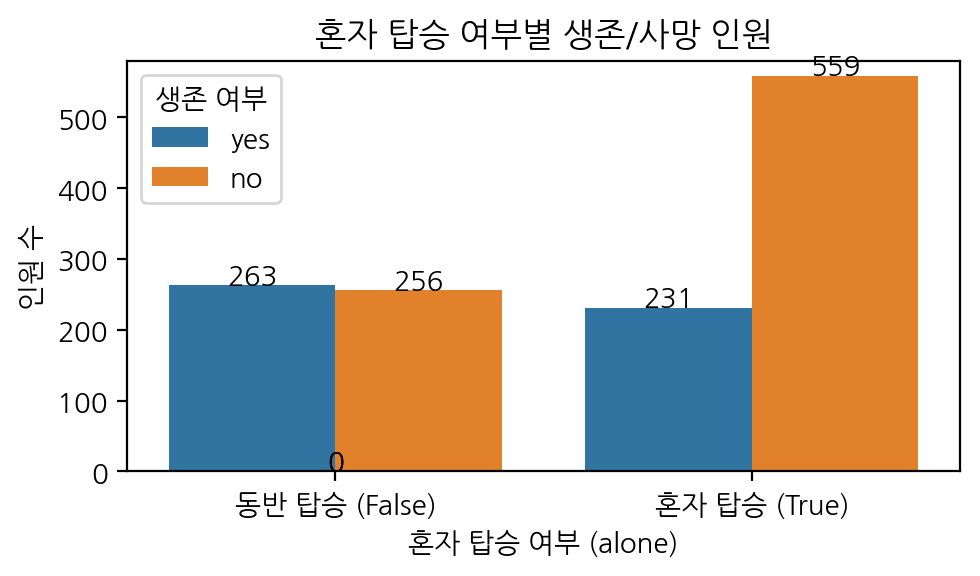

In [ ]:
# 동반자 유무로 확인

ax = sns.countplot(data=df, x='alone', hue='alive',
                   hue_order=['yes', 'no'])

for p in ax.patches:
    height = p.get_height()
    ax.text(x=(p.get_x() + p.get_width() / 2),
            y=(height + 2),
            s=int(height),
            ha='center', size=10, color='black')

ax.set_ylim(0, 580)

# x축 눈금 레이블을 읽기 쉽게 변경
ax.set_xticklabels(['동반 탑승 (False)', '혼자 탑승 (True)'])

plt.title('혼자 탑승 여부별 생존/사망 인원')
plt.xlabel('혼자 탑승 여부 (alone)')
plt.ylabel('인원 수')
plt.legend(title='생존 여부')
plt.tight_layout()
plt.show()

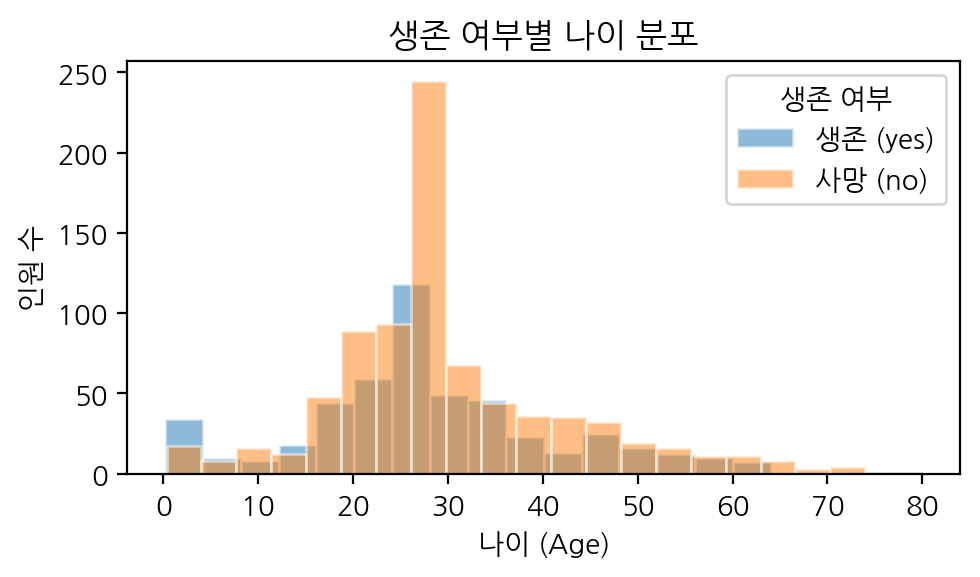

In [ ]:
# 나이별 생존사망 비교

survived = df[df['alive'] == 'yes']
dead = df[df['alive'] == 'no']

plt.hist(survived['Age'], bins=20, alpha=0.5, edgecolor='white', label='생존 (yes)')
plt.hist(dead['Age'], bins=20, alpha=0.5, edgecolor='white', label='사망 (no)')

plt.title('생존 여부별 나이 분포')
plt.xlabel('나이 (Age)')
plt.ylabel('인원 수')
plt.legend(title='생존 여부')
plt.tight_layout()
plt.show()

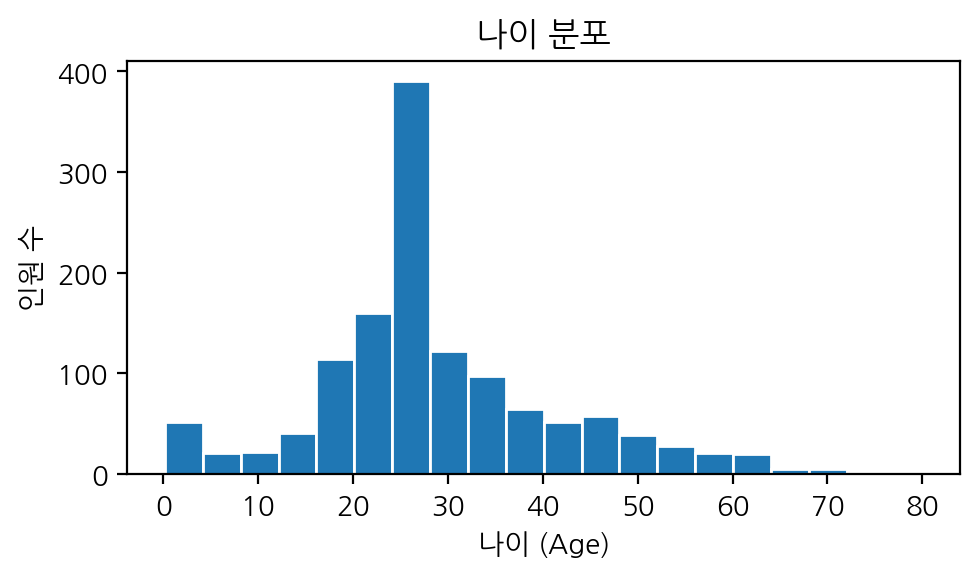

In [ ]:
# 탑승한 인원의 나이 분포

plt.hist(df['Age'], bins=20, edgecolor='white')

plt.title('나이 분포')
plt.xlabel('나이 (Age)')
plt.ylabel('인원 수')
plt.tight_layout()
plt.show()

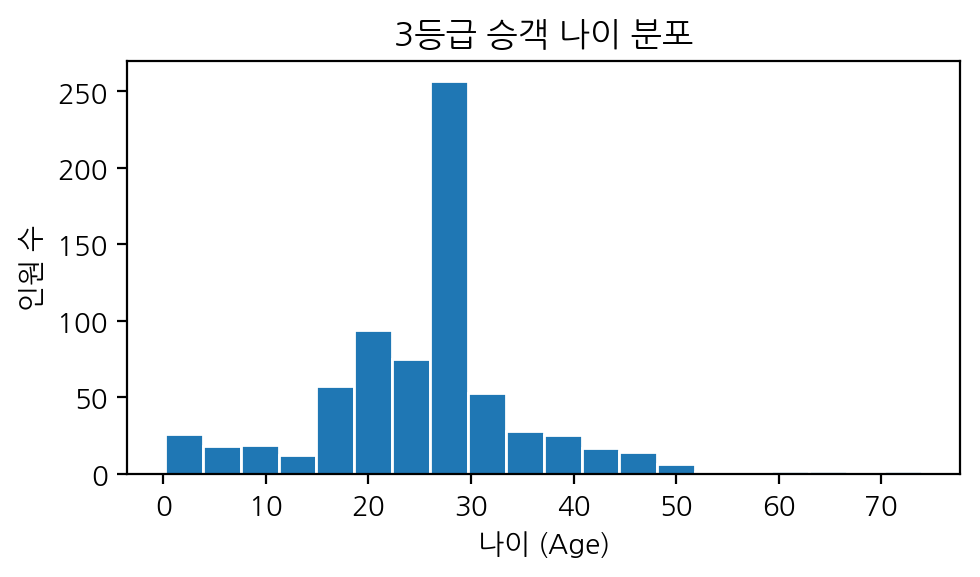

In [ ]:
# 3등급 승객만 필터링
third = df[df['class'] == 'Third']

plt.hist(third['Age'], bins=20, edgecolor='white')

plt.title('3등급 승객 나이 분포')
plt.xlabel('나이 (Age)')
plt.ylabel('인원 수')
plt.tight_layout()
plt.show()

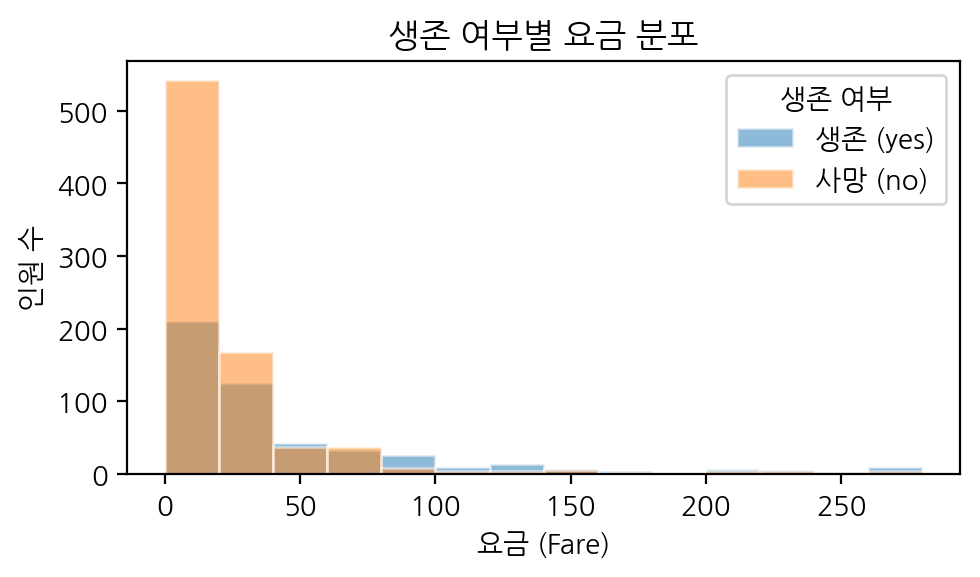

In [ ]:
survived = df[df['alive'] == 'yes']
dead     = df[df['alive'] == 'no']

plt.hist(survived['Fare'], bins=np.arange(0, 300, 20), alpha=0.5, edgecolor='white', label='생존 (yes)')
plt.hist(dead['Fare'],     bins=np.arange(0, 300, 20), alpha=0.5, edgecolor='white', label='사망 (no)')

plt.title('생존 여부별 요금 분포')
plt.xlabel('요금 (Fare)')
plt.ylabel('인원 수')
plt.legend(title='생존 여부')
plt.tight_layout()
plt.show()

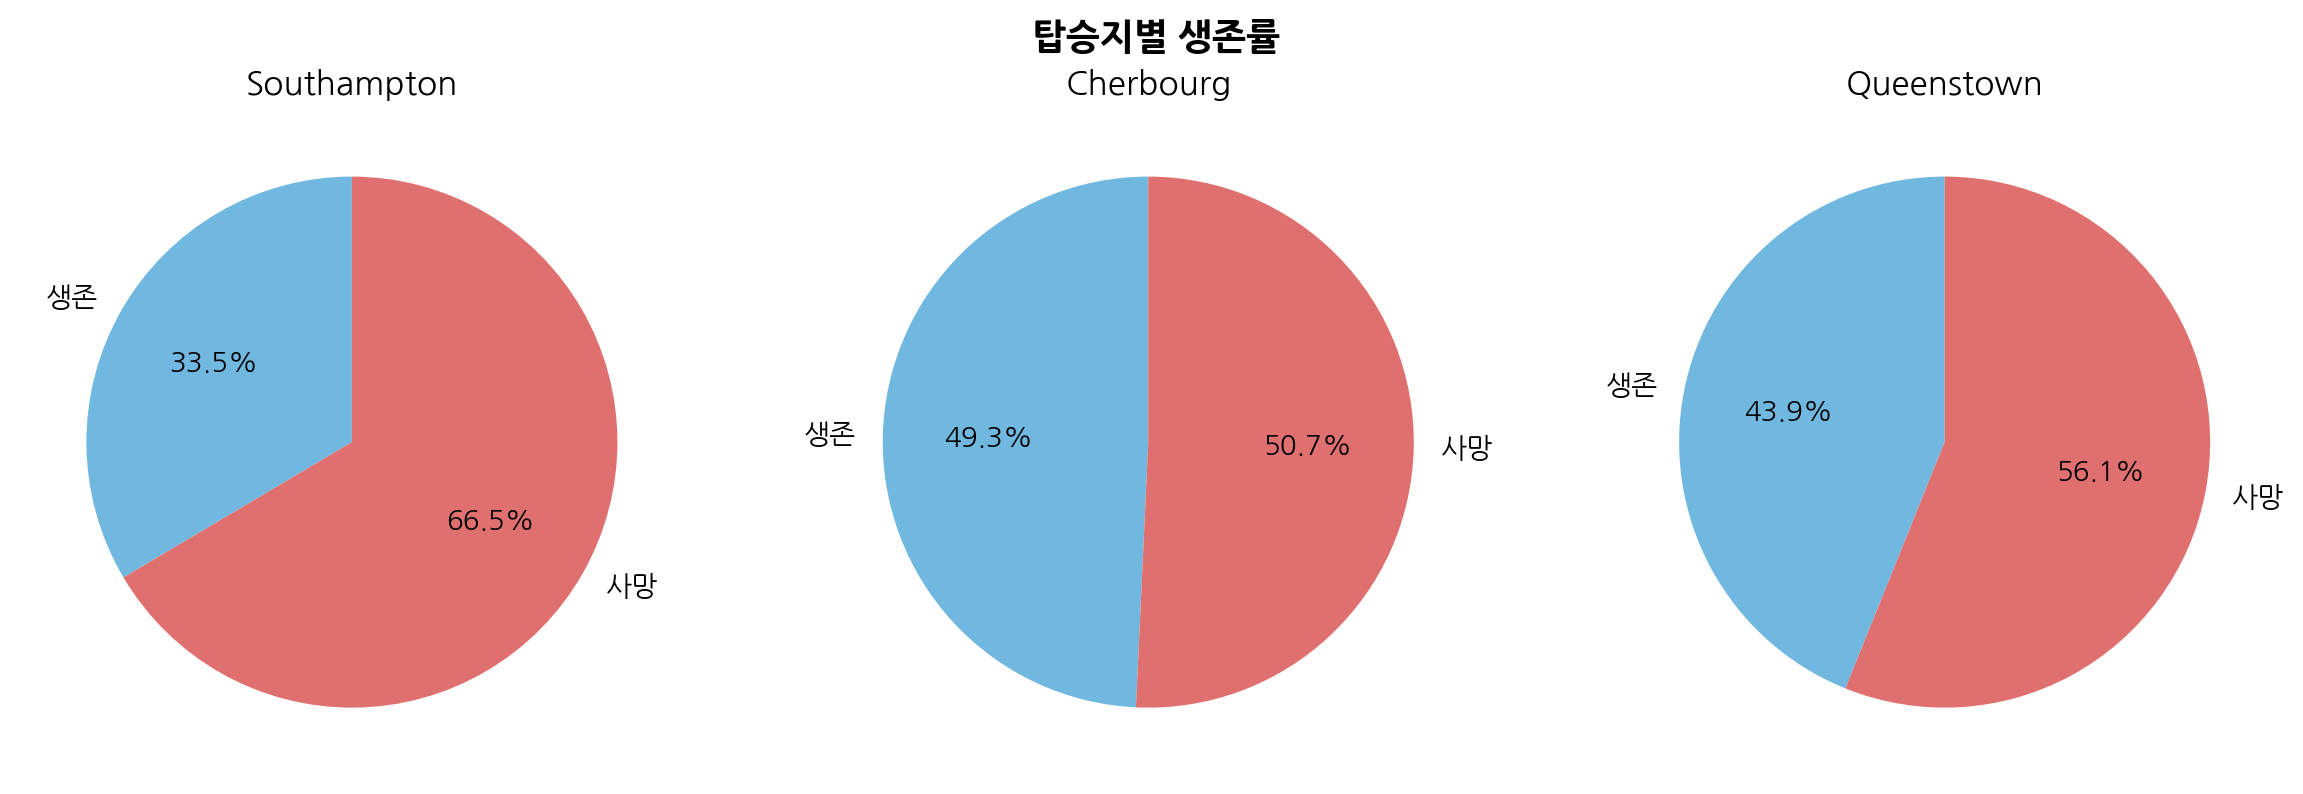

In [ ]:
# 파이차트
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

towns = ['Southampton', 'Cherbourg', 'Queenstown']
colors = ['#70b8e0', '#e07070']

for i, town in enumerate(towns):
    target = df[df['embark_town'] == town]
    counts = target['alive'].value_counts().reindex(['yes', 'no'])

    axes[i].pie(counts,
                labels=['생존', '사망'],
                autopct='%1.1f%%',
                colors=colors,
                startangle=90)
    axes[i].set_title(town)

plt.suptitle('탑승지별 생존률', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

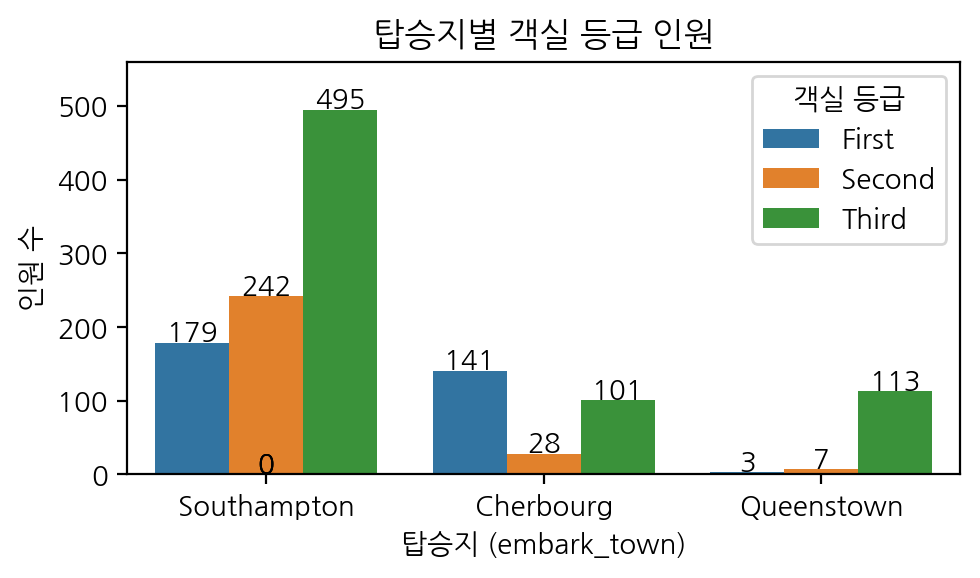

In [ ]:
# 탑승지 × 객실 등급 인원
ax = sns.countplot(data=df, x='embark_town', hue='class',
                   order=['Southampton', 'Cherbourg', 'Queenstown'],
                   hue_order=['First', 'Second', 'Third'])

for p in ax.patches:
    height = p.get_height()
    ax.text(x=(p.get_x() + p.get_width() / 2),
            y=(height + 2),
            s=int(height),
            ha='center', size=10, color='black')

ax.set_ylim(0, 560)
plt.title('탑승지별 객실 등급 인원')
plt.xlabel('탑승지 (embark_town)')
plt.ylabel('인원 수')
plt.legend(title='객실 등급')
plt.tight_layout()
plt.show()

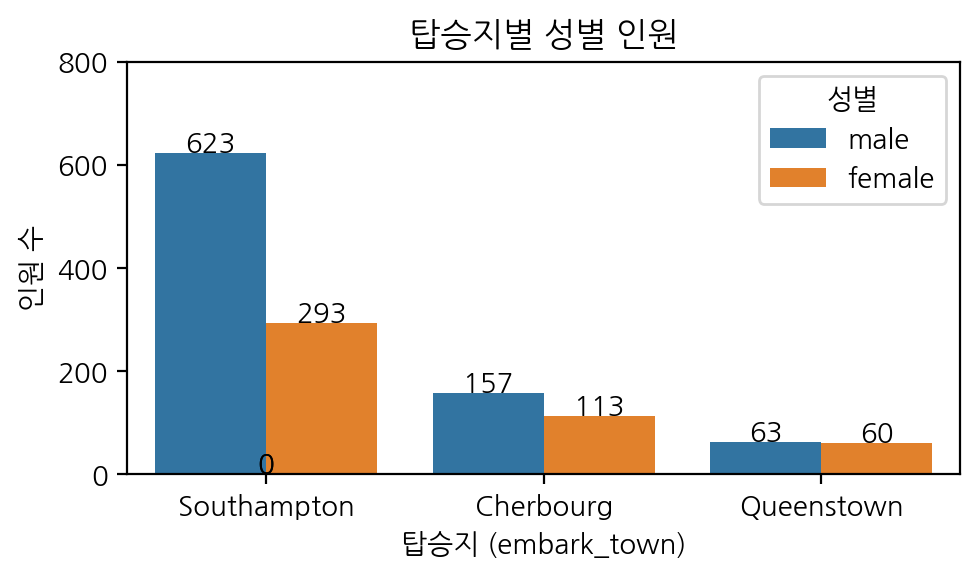

In [ ]:
# 탑승지 × 성별 인원
ax = sns.countplot(data=df, x='embark_town', hue='Sex',
                   order=['Southampton', 'Cherbourg', 'Queenstown'])

for p in ax.patches:
    height = p.get_height()
    ax.text(x=(p.get_x() + p.get_width() / 2),
            y=(height + 2),
            s=int(height),
            ha='center', size=10, color='black')

ax.set_ylim(0, 800)
plt.title('탑승지별 성별 인원')
plt.xlabel('탑승지 (embark_town)')
plt.ylabel('인원 수')
plt.legend(title='성별')
plt.tight_layout()
plt.show()